In [18]:
!pip install gradio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("/content/heart_disease_dataset.csv")
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [4]:
df.isnull().sum()

,0
Age,0
Gender,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Smoking,0
Alcohol Intake,340
Exercise Hours,0
Family History,0
Diabetes,0


In [5]:
df["Alcohol Intake"].fillna(df["Alcohol Intake"].mode()[0], inplace=True)

/tmp/ipython-input-286/1918498468.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Alcohol Intake"].fillna(df["Alcohol Intake"].mode()[0], inplace=True)


In [6]:
X = df[[
    "Age",
    "Cholesterol",
    "Blood Pressure",
    "Heart Rate",
    "Exercise Hours",
    "Stress Level",
    "Blood Sugar"
]]
y = df["Heart Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.88
Precision: 0.8536585365853658
Recall: 0.8536585365853658
F1 Score: 0.8536585365853658
Confusion Matrix:
 [[106  12]
 [ 12  70]]


KNN Accuracy: 0.885


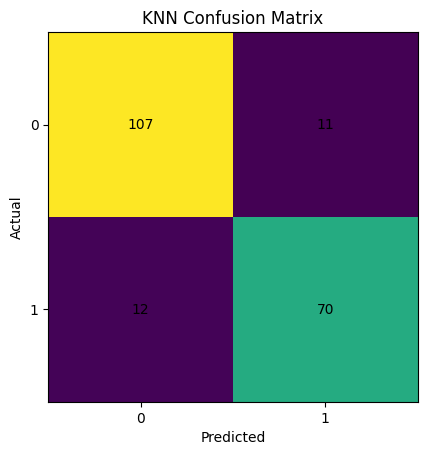

In [14]:
#KNN accuracy
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure()
plt.imshow(cm_knn)
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1])
plt.yticks([0,1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_knn[i, j], ha="center", va="center")
plt.show()

In [15]:
# Naive Bayes Accuracy
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.935


In [16]:
# Logistic Regression Accuracy
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.88


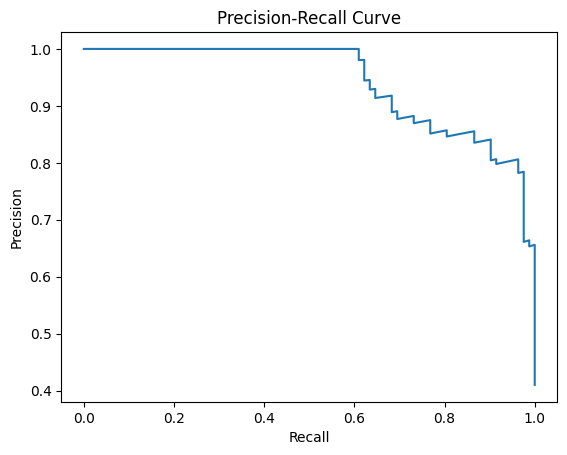

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

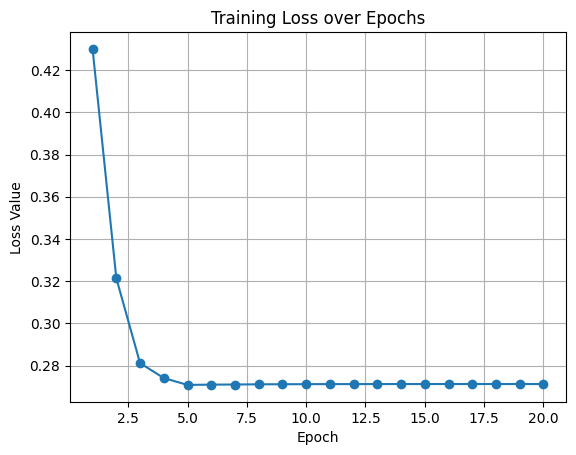

In [11]:
from sklearn.metrics import log_loss

epochs = 20
losses = []

temp_model = LogisticRegression(max_iter=1, warm_start=True)

for i in range(epochs):
    temp_model.fit(X_train, y_train)
    y_prob_temp = temp_model.predict_proba(X_train)
    loss = log_loss(y_train, y_prob_temp)
    losses.append(loss)
plt.figure()
plt.plot(range(1, epochs+1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

In [12]:
def predict(age, cholesterol, bp, heart_rate, exercise, stress, blood_sugar):

    input_data = np.array([[age, cholesterol, bp,
                            heart_rate, exercise,
                            stress, blood_sugar]])

    input_scaled = scaler.transform(input_data)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    if prediction == 1:
        return f"🔴 High Risk of Heart Disease ({probability*100:.2f}%)"
    else:
        return f"🟢 Low Risk of Heart Disease ({probability*100:.2f}%)"

interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Cholesterol"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Heart Rate"),
        gr.Number(label="Exercise Hours per Week"),
        gr.Number(label="Stress Level (1-10)"),
        gr.Number(label="Blood Sugar"),
    ],
    outputs="text",
    title="Heart Disease Prediction System",
    description="Enter patient health parameters to predict heart disease risk."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://833823027ff808f869.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
